In [1]:
import sys
import torch
from torch.utils.data import DataLoader

sys.path.append("../src")
from dataloader import MedleyDbDataset

DATASET_PATH = "../data/sample/TestSong"
dataset = MedleyDbDataset(dataset_root=DATASET_PATH, segment_length=256, max_freq=10000)
dataloader = DataLoader(dataset, batch_size=1)



MedleyDB structure not found. Falling back to flat directory search...


In [2]:
"""Shape Verification"""
batch_a, _ = next(iter(dataloader))

print(f"Input Spectrogram Shape: {batch_a.shape}")
print(f"Frequency Bins: {batch_a.shape[2]}")
print(f"Time Frames: {batch_a.shape[3]}")

Input Spectrogram Shape: torch.Size([1, 1, 464, 256])
Frequency Bins: 464
Time Frames: 256


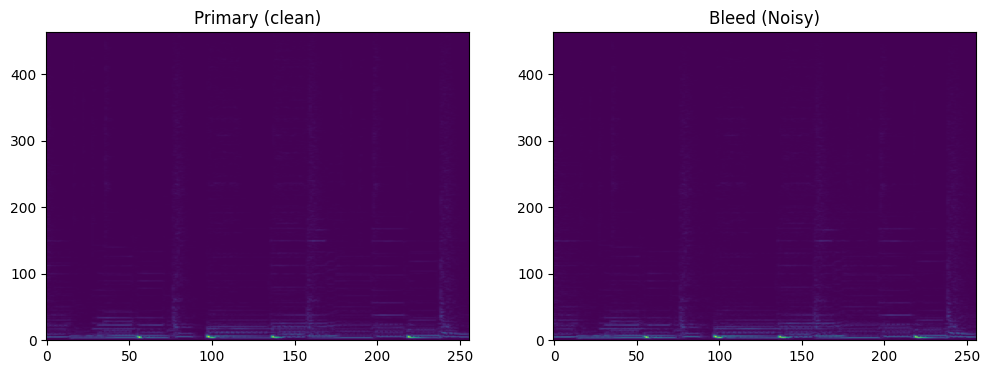

In [3]:
import matplotlib.pyplot as plt
#grab batch
batch_a, batch_b = next(iter(dataloader))

# spectrogram plot
fig, axes = plt.subplots(1, 2, figsize =(12,4))
axes[0].imshow(batch_a.squeeze().numpy(), origin='lower', aspect='auto')
axes[0].set_title("Primary (clean)")
axes[1].imshow(batch_b.squeeze().numpy(), origin='lower', aspect='auto')
axes[1].set_title("Bleed (Noisy)")
plt.show()
